In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Basic MLP
basic_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

basic_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_basic = basic_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    verbose=0
)

# MLP with Dropout
dropout_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    verbose=0
)

print("Basic Model Best Validation Accuracy:",
      max(history_basic.history['val_accuracy']))

print("Dropout Model Best Validation Accuracy:",
      max(history_dropout.history['val_accuracy']))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Basic Model Best Validation Accuracy: 0.9670329689979553
Dropout Model Best Validation Accuracy: 0.9780219793319702


In [2]:
from tensorflow.keras.layers import BatchNormalization

bn_model = Sequential([

    Dense(64, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),

    Dense(32),
    BatchNormalization(),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

bn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    verbose=1
)

test_loss, test_acc = bn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_acc)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.7775 - loss: 0.4947 - val_accuracy: 0.8901 - val_loss: 0.3463
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9505 - loss: 0.2151 - val_accuracy: 0.9341 - val_loss: 0.2346
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9560 - loss: 0.1632 - val_accuracy: 0.9341 - val_loss: 0.1825
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9643 - loss: 0.1150 - val_accuracy: 0.9341 - val_loss: 0.1585
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9560 - loss: 0.1127 - val_accuracy: 0.9341 - val_loss: 0.1430
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9780 - loss: 0.0807 - val_accuracy: 0.9231 - val_loss: 0.1373
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9835 - loss: 0.0658 - val_accuracy: 0.9231 - val_loss: 0.1316
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9753 - loss: 0.0689 - val_accuracy: 0.9341 - v

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

print("Training stopped after",
      len(history.history['loss']),
      "epochs")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6071 - loss: 0.6582 - val_accuracy: 0.9341 - val_loss: 0.4479
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9478 - loss: 0.3491 - val_accuracy: 0.9451 - val_loss: 0.2611
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.2127 - val_accuracy: 0.9451 - val_loss: 0.1799
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9643 - loss: 0.1507 - val_accuracy: 0.9451 - val_loss: 0.1422
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1166 - val_accuracy: 0.9451 - val_loss: 0.1228
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.0954 - val_accuracy: 0.9560 - val_loss: 0.1108
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0813 - val_accuracy: 0.9670 - val_loss: 0.1027
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9890 - loss: 0.0707 - val_accuracy: 0.9670 - 

Adam Best Validation Accuracy: 0.9670329689979553
SGD Best Validation Accuracy: 0.9560439586639404


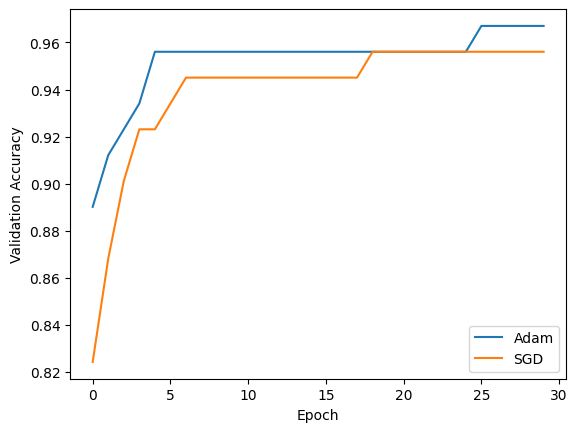

In [4]:
from tensorflow.keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt

# Adam Model
adam_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

adam_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_adam = adam_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    verbose=0
)

# SGD Model
sgd_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    verbose=0
)

print("Adam Best Validation Accuracy:",
      max(history_adam.history['val_accuracy']))

print("SGD Best Validation Accuracy:",
      max(history_sgd.history['val_accuracy']))

plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()